# Page Rank

## Liberary

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re, sys, time
from urllib.parse import urljoin, urlparse
import urllib3
import networkx as nx
import matplotlib.pyplot as plt

## Fungsi Crawling

In [3]:
def print_progress2(kategori, current_page, total_pages):
    percent = (current_page / total_pages) * 100
    bar_length = 20
    filled_length = int(bar_length * current_page // total_pages)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    sys.stdout.write(f'\r{kategori} - Page {current_page}/{total_pages} [{bar}] {percent:.2f}%')
    sys.stdout.flush()
    if current_page == total_pages:
        sys.stdout.write('\n\n')
# matikan warning SSL insecure
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def scrape_all_links(base_url, max_pages=50):
    visited = set()
    results = []
    current_page = 0

    def scrape_page(url):
        nonlocal current_page
        try:
            response = requests.get(url, verify=False, timeout=10)
            soup = BeautifulSoup(response.text, 'html.parser')

            # ambil semua link keluar
            for a in soup.find_all('a', href=True):
                href = a['href'].strip()
                if not href or href == "#":
                    continue
                full_link = urljoin(url, href)
                results.append({
                    "Page": url,
                    "Link Keluar": full_link
                })

            # update progress setiap selesai 1 page
            current_page += 1
            print_progress2("Scraping", current_page, max_pages)

            # cari link internal untuk dilanjutkan
            for a in soup.find_all('a', href=True):
                href = a['href'].strip()
                if not href or href == "#":
                    continue
                full_link = urljoin(url, href)
                # hanya ambil link internal
                if full_link.startswith(base_url) and full_link not in visited:
                    visited.add(full_link)
                    if len(visited) < max_pages:
                        scrape_page(full_link)

        except Exception as e:
            print(f"⚠️ Gagal akses {url}: {e}")

    # mulai dari base_url
    visited.add(base_url)
    scrape_page(base_url)

    # rapikan dataframe dan simpan CSV
    df = pd.DataFrame(results).reset_index(drop=True)
    df.index += 1
    df.insert(0, "No", df.index)
    df.to_csv("link.csv", index=False, encoding="utf-8-sig")

    print("\n✅ Seluruh data berhasil dikumpulkan!")
    print(f"📊 Total entri: {len(df)}")

    return None

In [6]:
url = "https://informatika.trunojoyo.ac.id/"
scrape_all_links(url, max_pages=30)

Scraping - Page 29/30 [███████████████████-] 96.67%
✅ Seluruh data berhasil dikumpulkan!
📊 Total entri: 1686


In [7]:
link = pd.read_csv("link.csv")
link

,No,Page,Link Keluar
0,1,https://informatika.trunojoyo.ac.id/,https://informatika.trunojoyo.ac.id/
1,2,https://informatika.trunojoyo.ac.id/,https://informatika.trunojoyo.ac.id/bidang-min...
2,3,https://informatika.trunojoyo.ac.id/,https://informatika.trunojoyo.ac.id/bidang-min...
3,4,https://informatika.trunojoyo.ac.id/,https://informatika.trunojoyo.ac.id/bidang-min...
4,5,https://informatika.trunojoyo.ac.id/,https://informatika.trunojoyo.ac.id/bidang-min...
...,...,...,...
1681,1682,https://informatika.trunojoyo.ac.id/unit-kegia...,https://tofatek.wordpress.com/
1682,1683,https://informatika.trunojoyo.ac.id/unit-kegia...,https://informatika.trunojoyo.ac.id/berita-pro...
1683,1684,https://informatika.trunojoyo.ac.id/unit-kegia...,https://informatika.trunojoyo.ac.id/berita-pro...
1684,1685,https://informatika.trunojoyo.ac.id/unit-kegia...,https://informatika.trunojoyo.ac.id/berita-pro...


## Data preparation

In [9]:
edges = link[['Page', 'Link Keluar']].copy()

# Tentukan node unik
nodes = pd.Index(sorted(set(edges['Page']).union(edges['Link Keluar'])))
n = len(nodes)
print(f"Jumlah node: {n}")

# Buat mapping node → index
node_to_index = {node: i for i, node in enumerate(nodes)}

Jumlah node: 157


### Matriks adjacency

In [ ]:
A = np.zeros((n, n), dtype=float)
for _, row in edges.iterrows():
    i = node_to_index[row['Page']]
    j = node_to_index[row['Link Keluar']]
    A[j, i] = 1  # arah Page → Link Keluar

In [ ]:
col_sums = A.sum(axis=0)
for j in range(n):
    if col_sums[j] == 0:
        A[:, j] = 1.0 / n    # dangling node → teleportasi penuh
    else:
        A[:, j] /= col_sums[j]

## Iterasi

In [ ]:
r = np.ones(n) / n
d = 0.85
epsilon = 1e-6
iteration = 0

while True:
    r_new = d * A @ r + (1 - d) / n
    diff = np.linalg.norm(r_new - r, 1)
    iteration += 1
    print(f"Iterasi {iteration}: diff = {diff:.8f}")
    if diff < epsilon:
        break
    r = r_new

Iterasi 1: diff = 0.17863128
Iterasi 2: diff = 0.05058169
Iterasi 3: diff = 0.01432284
Iterasi 4: diff = 0.00405569
Iterasi 5: diff = 0.00114842
Iterasi 6: diff = 0.00032519
Iterasi 7: diff = 0.00009208
Iterasi 8: diff = 0.00002607
Iterasi 9: diff = 0.00000738
Iterasi 10: diff = 0.00000209
Iterasi 11: diff = 0.00000059


In [13]:
# === 5. Hasil PageRank ===
Pagerank_df = pd.DataFrame({
    'Page': nodes,
    'PageRank': r
}).sort_values(by='PageRank', ascending=False)

print("Top 5 page dengan PageRank tertinggi:")
Pagerank_df.head(5)

Top 5 page dengan PageRank tertinggi:


,Page,PageRank
156,https://youtube.com/@teknikinformatikautm,0.008885
155,https://www.instagram.com/tifutm.official,0.008885
113,https://informatika.trunojoyo.ac.id/laboratori...,0.008885
130,https://informatika.trunojoyo.ac.id/pengumuman,0.008885
129,https://informatika.trunojoyo.ac.id/labtif/dos...,0.008885


## Visualisasi 10 Node tertinggi

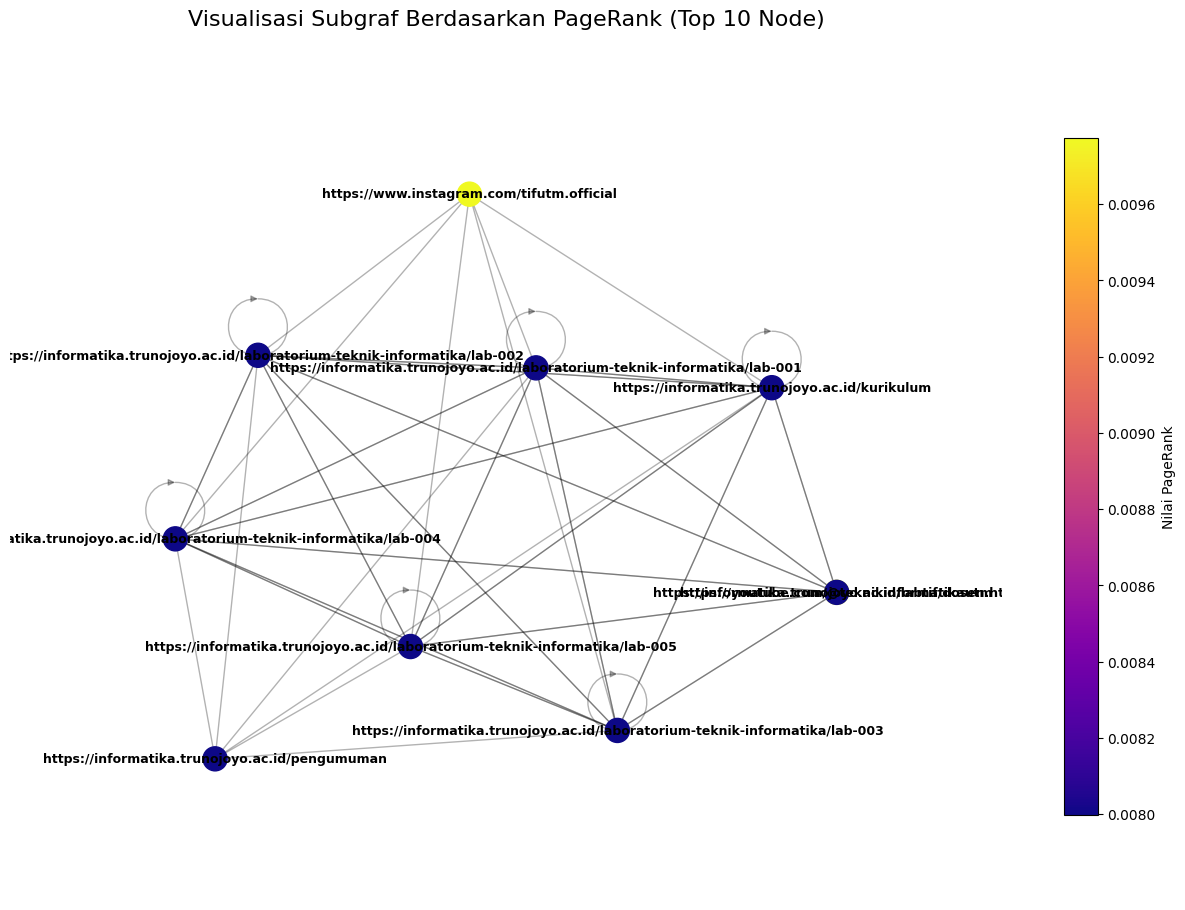

In [14]:
# === 6. Buat Graph untuk Visualisasi ===
edges_viz = edges.rename(columns={'Page': 'From', 'Link Keluar': 'To'})
G = nx.DiGraph()
G.add_edges_from(edges_viz.itertuples(index=False, name=None))

# Ambil 10 node dengan PageRank tertinggi
top_nodes = Pagerank_df.head(10)['Page'].tolist()
H = G.subgraph(top_nodes).copy()

# Warna berdasarkan nilai PageRank
pr_sub = dict(zip(Pagerank_df['Page'], Pagerank_df['PageRank']))
node_colors = [pr_sub.get(n, 0) for n in H.nodes()]

# === 7. Visualisasi Graf ===
fig, ax = plt.subplots(figsize=(16, 11))
pos = nx.kamada_kawai_layout(H)

# Gambar node dan edge
nx.draw_networkx_nodes(
    H, pos,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    node_size=300,
    ax=ax
)
nx.draw_networkx_edges(H, pos, alpha=0.3, arrows=False, ax=ax)

# Tambahkan label node
nx.draw_networkx_labels(
    H, pos,
    font_size=9,
    font_color='black',
    font_weight='bold',
    verticalalignment='center',
    horizontalalignment='center',
    ax=ax
)

# Hitung batas posisi node untuk perluasan area gambar
x_values = [p[0] for p in pos.values()]
y_values = [p[1] for p in pos.values()]
x_margin = (max(x_values) - min(x_values)) * 0.25
y_margin = (max(y_values) - min(y_values)) * 0.25

ax.set_xlim(min(x_values) - x_margin, max(x_values) + x_margin)
ax.set_ylim(min(y_values) - y_margin, max(y_values) + y_margin)

# Tambahkan judul dan colorbar
ax.set_title("Visualisasi Subgraf Berdasarkan PageRank (Top 10 Node)", fontsize=16, pad=20)
ax.axis("off")

sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma)
sm.set_array(node_colors)
plt.colorbar(sm, label="Nilai PageRank", ax=ax, shrink=0.8)

plt.show()